In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv('car_fuel_efficiency.csv')

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


### EDA

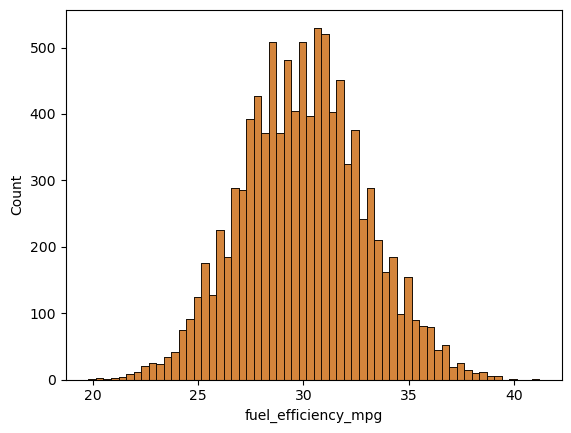

In [4]:
sns.histplot(df['fuel_efficiency_mpg'])
plt.show()

In [31]:
# No need for np.log1p

### Question 1

In [5]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [6]:
cols_to_use = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']

In [7]:
df = df[cols_to_use]

df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### Question 2

In [8]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


In [33]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

### Question 3

In [34]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7


In [35]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [36]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7


In [37]:
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

In [38]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [39]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

#### Option 1: 0

In [40]:
df_train_option_0 = df_train.copy()

df_train_option_0.horsepower = df_train_option_0.horsepower.fillna(0)

In [41]:

df_train_option_0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [42]:
X_train = df_train_option_0.values

In [43]:
w0, w = train_linear_regression(X_train, y_train)

In [44]:
df_val_option_0 = df_val.copy()

df_val_option_0.horsepower = df_val_option_0.horsepower.fillna(0)

In [45]:
X_val = df_val_option_0.values

In [46]:
y_pred = w0 + X_val.dot(w)

In [47]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()

    return np.sqrt(mse)

In [50]:
round(rmse(y_val, y_pred), 3)

2.205

#### Option 2: Mean

In [51]:
df_train_option_mean = df_train.copy()

In [52]:
df_train_option_mean.horsepower.mean()

254.46338337605272

In [53]:
df_train_option_mean.horsepower = df_train_option_mean.horsepower.fillna(df_train_option_mean.horsepower.mean())

In [54]:
df_train_option_mean.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [55]:
X_train = df_train_option_mean.values

In [56]:
w0, w = train_linear_regression(X_train, y_train)

In [59]:
df_val_option_mean = df_val.copy()

df_val_option_mean.horsepower = df_val_option_mean.horsepower.fillna(254.46338337605272)

In [60]:
X_val = df_val_option_mean.values

In [61]:
y_pred = w0 + X_val.dot(w)

In [62]:
round(rmse(y_val, y_pred), 3)

2.202

### Question 4

In [71]:
# Ridge regression adds a factor to the diagonals of the Gram matrix
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + (r * np.eye(XTX.shape[0]))
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [72]:
X_train = df_train_option_0.values
X_val = df_val_option_0.values

In [73]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r)

    y_pred = w0 + X_val.dot(w)

    score = round(rmse(y_val, y_pred), 4)

    print(f'{r:<4} - {score}')

0    - 2.2053
0.01 - 2.2058
0.1  - 2.2241
1    - 2.3492
5    - 2.4094
10   - 2.4195
100  - 2.4292


### Question 5

In [76]:
list_rmse = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg
    y_val = df_val.fuel_efficiency_mpg
    y_test = df_test.fuel_efficiency_mpg

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    df_train_option_0 = df_train.copy()
    df_train_option_0.horsepower = df_train_option_0.horsepower.fillna(0)   

    df_val_option_0 = df_val.copy()
    df_val_option_0.horsepower = df_val_option_0.horsepower.fillna(0)

    X_train = df_train_option_0.values
    X_val = df_val_option_0.values

    w0, w = train_linear_regression(X_train, y_train)

    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)

    list_rmse.append(score)
    print(f'{seed} - {score}')
    

0 - 2.239204143046126
1 - 2.2021128210838845
2 - 2.1634197787530947
3 - 2.2043588768539224
4 - 2.2018800943311554
5 - 2.2457851509085134
6 - 2.2697212079524043
7 - 2.190794599933443
8 - 2.216611201686444
9 - 2.2070365928178957


In [77]:
std_dev = np.std(list_rmse)

In [79]:
round(std_dev, 3)

0.029

### Question 6

In [96]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_full_train = pd.concat([df_train, df_val])

df_full_train = df_full_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_full_train = df_full_train.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

del df_full_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

df_full_train_option_0 = df_full_train.copy()
df_full_train_option_0.horsepower = df_full_train_option_0.horsepower.fillna(0)   

df_test_option_0 = df_test.copy()
df_test_option_0.horsepower = df_test_option_0.horsepower.fillna(0)

X_full_train = df_full_train_option_0.values
X_test = df_test_option_0.values

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)

print(score)
    

2.235827747191731
